In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set style for plots
sns.set_style('whitegrid')

In [4]:
# Load the dataset
df = pd.read_csv('../data/processed_dataset.csv')
print('Dataset shape:', df.shape)
print('Columns:', list(df.columns))
df.head()

Dataset shape: (20000, 18)
Columns: ['Unnamed: 0', 'name', 'age', 'has_eye_disease', 'has_diabetic_retinopathy', 'sugar_percentage', 'glucose_percentage', 'cholesterol_percentage', 'obesity_percentage', 'blood_pressure', 'heart_rate', 'systolic', 'diastolic', 'bp_category', 'obesity_group', 'metabolic_risk_count', 'metabolic_syndrome_flag', 'health_risk_score']


,Unnamed: 0,name,age,has_eye_disease,has_diabetic_retinopathy,sugar_percentage,glucose_percentage,cholesterol_percentage,obesity_percentage,blood_pressure,heart_rate,systolic,diastolic,bp_category,obesity_group,metabolic_risk_count,metabolic_syndrome_flag,health_risk_score
0,0,Patient 1,39,False,False,5.70,147.48,164.45,32.94,122/63,94,122,63,elevated,obese,2,True,48.002569
1,1,Patient 2,67,True,False,8.72,91.52,235.62,39.58,92/80,68,92,80,stage_1,obese,2,True,44.561545
2,2,Patient 3,44,True,False,13.83,160.17,299.13,38.45,140/60,67,140,60,stage_2,obese,4,True,73.000519
3,3,Patient 4,46,True,True,9.48,106.84,236.75,29.10,132/83,82,132,83,stage_1,overweight,2,True,61.675717
4,4,Patient 5,39,False,False,5.60,158.65,182.11,16.25,128/72,63,128,72,elevated,underweight,1,False,34.566440


In [5]:
# Basic statistics
df.describe()

,Unnamed: 0,age,sugar_percentage,glucose_percentage,cholesterol_percentage,obesity_percentage,heart_rate,systolic,diastolic,metabolic_risk_count,health_risk_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,9999.500000,54.924350,9.481480,135.056622,199.907359,27.492396,79.915700,115.013350,75.037000,1.68065,50.975397
std,5773.647028,14.624655,3.178785,37.613572,58.094403,7.218316,11.777238,14.672441,8.947063,0.95090,13.395650
min,0.000000,30.000000,4.000000,70.010000,100.020000,15.000000,60.000000,90.000000,60.000000,0.00000,0.000000
25%,4999.750000,42.000000,6.720000,102.520000,149.207500,21.230000,70.000000,102.000000,67.000000,1.00000,41.798495
50%,9999.500000,55.000000,9.460000,135.280000,199.760000,27.460000,80.000000,115.000000,75.000000,2.00000,50.915286
75%,14999.250000,67.000000,12.230000,167.705000,250.202500,33.770000,90.000000,128.000000,83.000000,2.00000,60.207807
max,19999.000000,80.000000,15.000000,200.000000,300.000000,40.000000,100.000000,140.000000,90.000000,4.00000,100.000000


In [6]:
# Check for missing values
df.isnull().sum()

Unnamed: 0                  0
name                        0
age                         0
has_eye_disease             0
has_diabetic_retinopathy    0
sugar_percentage            0
glucose_percentage          0
cholesterol_percentage      0
obesity_percentage          0
blood_pressure              0
heart_rate                  0
systolic                    0
diastolic                   0
bp_category                 0
obesity_group               0
metabolic_risk_count        0
metabolic_syndrome_flag     0
health_risk_score           0
dtype: int64

In [7]:
# Data types
df.dtypes

Unnamed: 0                    int64
name                         object
age                           int64
has_eye_disease                bool
has_diabetic_retinopathy       bool
sugar_percentage            float64
glucose_percentage          float64
cholesterol_percentage      float64
obesity_percentage          float64
blood_pressure               object
heart_rate                    int64
systolic                      int64
diastolic                     int64
bp_category                  object
obesity_group                object
metabolic_risk_count          int64
metabolic_syndrome_flag        bool
health_risk_score           float64
dtype: object

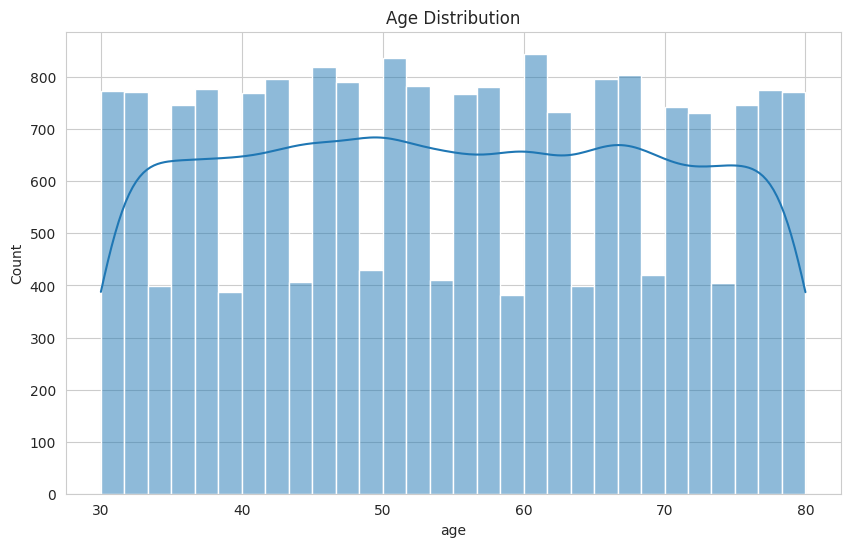

In [9]:
# EDA: Distribution of age
plt.figure(figsize=(10,6))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.savefig('../viz/age_distribution.png')
plt.show()

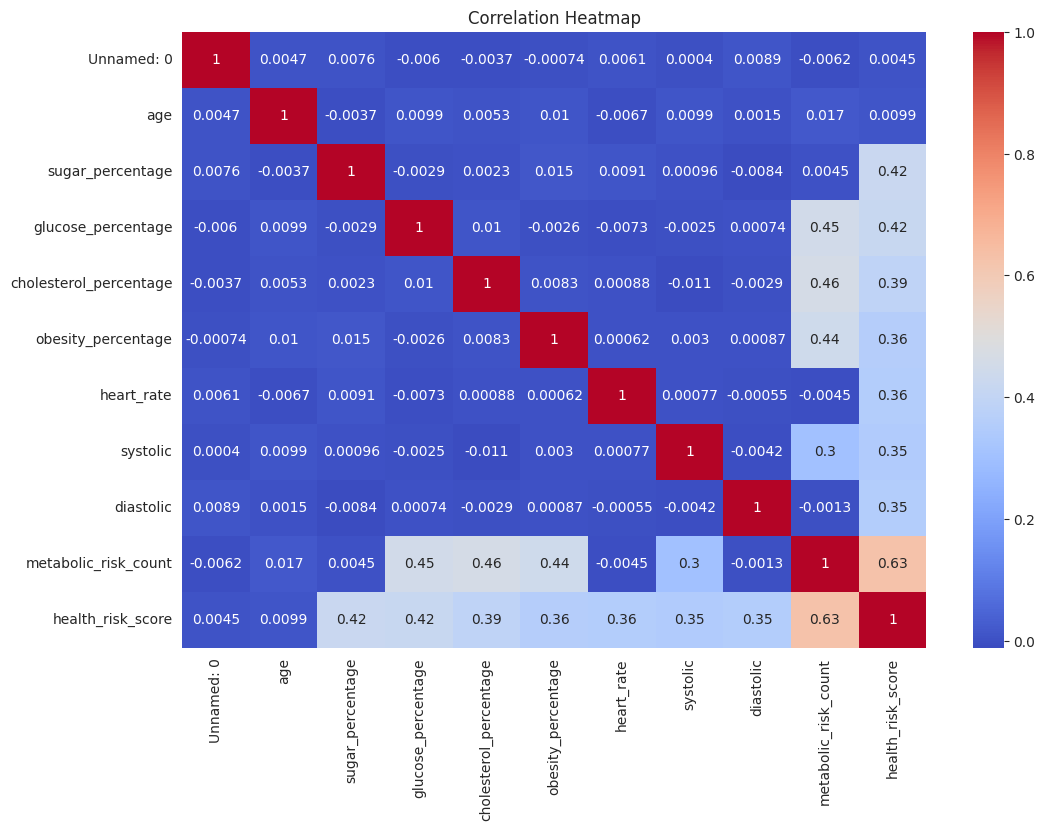

In [11]:
# EDA: Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('../viz/correlation_heatmap.png')
plt.show()

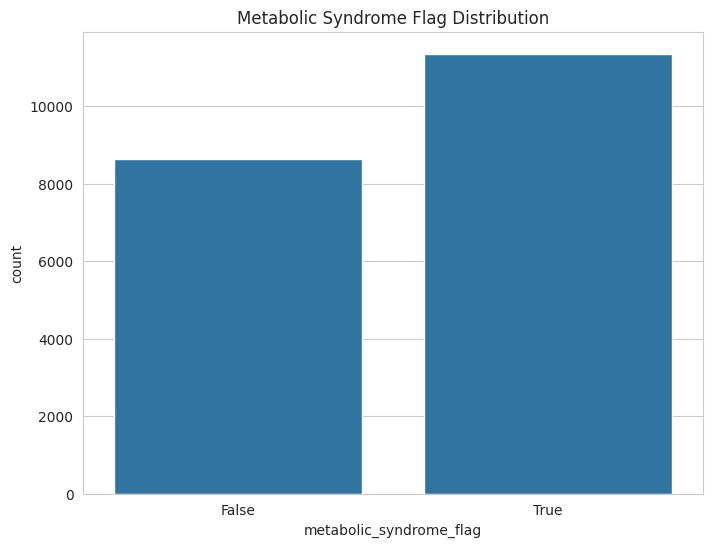

In [13]:
# EDA: Metabolic syndrome flag distribution
plt.figure(figsize=(8,6))
sns.countplot(x='metabolic_syndrome_flag', data=df)
plt.title('Metabolic Syndrome Flag Distribution')
plt.savefig('../viz/metabolic_syndrome_distribution.png')
plt.show()

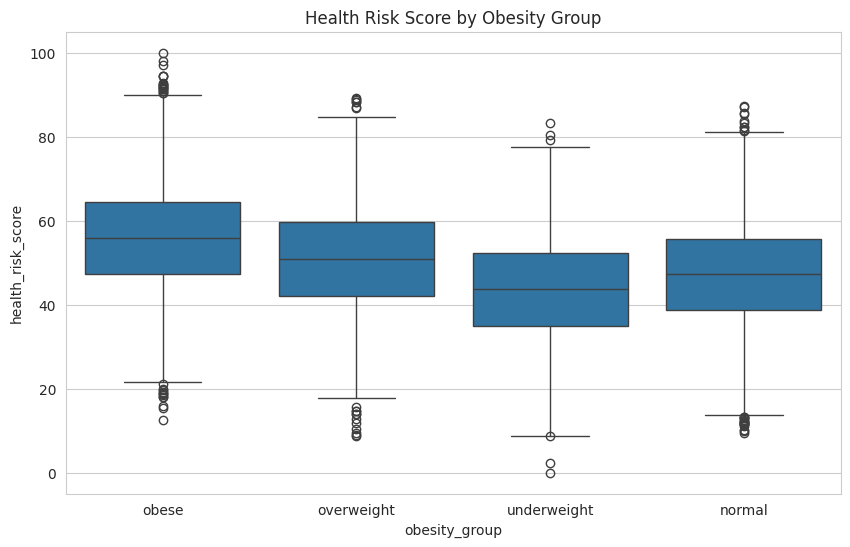

In [15]:
# EDA: Health risk score by obesity group
plt.figure(figsize=(10,6))
sns.boxplot(x='obesity_group', y='health_risk_score', data=df)
plt.title('Health Risk Score by Obesity Group')
plt.savefig('../viz/risk_score_by_obesity.png')
plt.show()

In [17]:
# Preprocessing for ML
# Encode categorical variables
le_bp = LabelEncoder()
df['bp_category_encoded'] = le_bp.fit_transform(df['bp_category'])

le_obesity = LabelEncoder()
df['obesity_group_encoded'] = le_obesity.fit_transform(df['obesity_group'])

# Select features
features = ['age', 'sugar_percentage', 'glucose_percentage', 'cholesterol_percentage', 'obesity_percentage', 'heart_rate', 'systolic', 'diastolic', 'bp_category_encoded', 'obesity_group_encoded', 'metabolic_risk_count']
X = df[features]
y = df['metabolic_syndrome_flag']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      1704
        True       1.00      1.00      1.00      2296

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



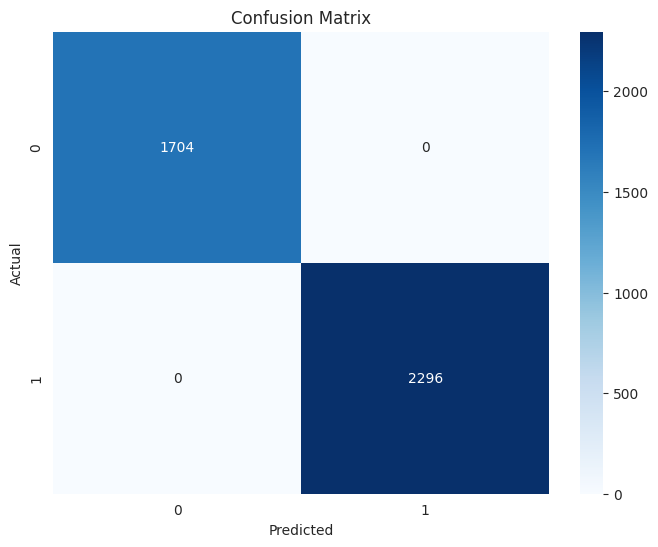

In [19]:
# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf_model.predict(X_test_scaled)

# Evaluation
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../viz/confusion_matrix.png')
plt.show()

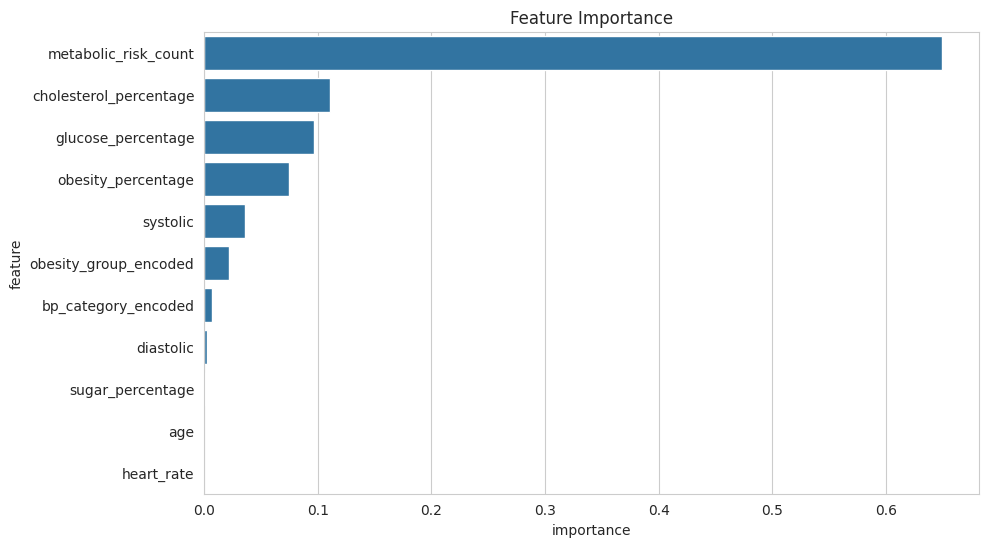

In [20]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance')
plt.savefig('../viz/feature_importance.png')
plt.show()

In [21]:
# Create a pipeline for the model
from sklearn.pipeline import Pipeline

# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Fit the pipeline
pipeline.fit(X_train, y_train)

# Example prediction
# Create a sample patient data
sample_patient = pd.DataFrame({
    'age': [50],
    'sugar_percentage': [8.0],
    'glucose_percentage': [140.0],
    'cholesterol_percentage': [200.0],
    'obesity_percentage': [35.0],
    'heart_rate': [75],
    'systolic': [130],
    'diastolic': [85],
    'bp_category_encoded': [le_bp.transform(['stage_1'])[0]],  # Encode 'stage_1'
    'obesity_group_encoded': [le_obesity.transform(['obese'])[0]],  # Encode 'obese'
    'metabolic_risk_count': [3]
})

# Make prediction
prediction = pipeline.predict(sample_patient)
prediction_proba = pipeline.predict_proba(sample_patient)

print('Sample Patient Prediction:')
print('Predicted Metabolic Syndrome:', prediction[0])
print('Prediction Probabilities:', prediction_proba[0])
print('(False, True) - Probability of no syndrome vs. syndrome')

Sample Patient Prediction:
Predicted Metabolic Syndrome: True
Prediction Probabilities: [0. 1.]
(False, True) - Probability of no syndrome vs. syndrome
